# Phase 2 — Notebook 04 · Stage 2.2 a + b · Hash-aware Design B (mean pool **and** attention pool)

**Why this notebook exists.** Across notebooks 01–03 (60 trained models on session 5_6) we observed a stable pattern:

* Within-session balanced accuracy ceiling at ≈ 0.50 regardless of representation (E1 / E0) or training objective (Design A / Design B).
* No positive Δ_temporal anywhere, no positive Δ_amplitude anywhere — kinetics claims are forbidden by §11 with these results.
* **L2/3 recall systematically collapses to 0.10–0.29** while L6 recall is pinned at 0.91–0.99.

The user's revised `PHASE2_PLANNING.md` §Stage 2.2 diagnoses this as a **structural limitation**: trace-only CNNs see calcium traces but are not told *which oracle stimulus generated each trace*. Tier G (which reaches 0.663 GKF) explicitly encodes per-hash response amplitudes as feature columns, so it can learn `(high response to hash A AND low to hash B) → L2/3` — a stimulus-conditioned pattern. Trace-only Design B cannot learn this because every trace looks like "some calcium response from neuron i" with no stimulus identity attached.

This notebook tests whether **adding hash identity as a learned embedding** restores the stimulus-indexed structure that Tier G has and our trace-only CNN was missing. We run **two pooling variants in the same notebook** so the comparison is paired by fold, by seed, and by data:

1. **Stage 2.2a — mean pooling** (clean test of whether hash identity helps).
2. **Stage 2.2b — attention pooling** (whether some hashes are more informative than others for the layer signal — especially for L2/3).

Together with the **trace-only Design B baseline from notebook 02**, this gives a three-way comparison on identical 5-fold GKF folds.

**Architecture (planning §Stage 2.2a / 2.2b):**

$$
\begin{aligned}
e_{i,h}^{\text{trace}} &= \text{Encoder}_{\text{CNN}}(x_{i,h}) \\
e_h^{\text{hash}}      &= \text{Embedding}(\text{condition\_hash}_h) \\
z_{i,h}                &= [e_{i,h}^{\text{trace}}, e_h^{\text{hash}}] \\
u_{i,h}                &= \text{MLP}(z_{i,h}) \\
u_i^{\text{mean}}      &= \frac{1}{H_i}\sum_h u_{i,h} \quad\text{(Stage 2.2a)} \\
u_i^{\text{attn}}      &= \sum_h \alpha_{i,h}\,u_{i,h}, \quad \alpha_{i,h} = \text{softmax}_h\!\bigl(w^\top \tanh(W u_{i,h})\bigr) \quad\text{(Stage 2.2b)} \\
p_i(y)                 &= \text{Classifier}(u_i)
\end{aligned}
$$

**Methodological notes (binding):**

1. **Reportable as `E1 Design B + hash identity`, NOT as trace-only.** Per planning lines 638–639, any improvement here is no longer evidence that the *trace alone* contains layer signal; it is evidence that the trace **combined with stimulus identity** does.
2. **Pure-hash baseline is automatic, not needed.** A model with no trace would produce identical pooled embeddings for every neuron (the hash table is shared) — degenerate. So the *trace* must do real per-neuron work for any gain. This is by design.
3. **No leakage from the hash embedding.** GroupKFold splits by `nucleus_id`; every oracle hash appears in train and held-out test (with disjoint neurons). The hash embedding learns generalisable per-stimulus parameters.
4. **Same 5 GKF folds, same population, same session 5_6** as notebooks 01–02. Per-fold seeds = `SEED + fold_k = {42, 43, 44, 45, 46}`. The mean-pool and attention-pool models share the same seeds; the *only* architectural difference between them is the pooling layer.
5. **Single condition: `raw_identity`.** Per planning §Stage 2.2a, the first hash-aware notebook only runs raw — controls and baseline-subtracted are deferred to later notebooks if and only if the winning hash-aware model clears the §Stage 2.2b threshold.
6. **Order of comparison.** §Stage 2.2b line 716: "If the mean-pooling hash-aware model is stable, the next variant is attention pooling." Running both here in one notebook does not violate that order — we read the mean-pool result first and only treat the attention-pool result as the *new candidate* if its **validation** metrics improve over mean pool, per §Stage 2.2b line 696: *"only if it improves validation metrics, not only training metrics."*

**Decision criteria** (planning §Stage 2.2b line 506):

> *"Prefer switching architecture only if the gain is approximately ≥ 0.03 balanced accuracy and is accompanied by better macro-F1 or more balanced per-class recall."*

Diagnostic target (planning §Stage 2.2 line 944): **L2/3 recall**.

Outputs: `data/processed/results/phase2_stage2_2a_hash_aware_design_b.parquet` (per-fold + summary rows for **both** mean-pool and attention-pool variants).

## 0 · Environment

In [1]:
import os, sys, time, warnings
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import GroupKFold

from src.config import PROCESSED_RESULTS_DIR
from src.data.loaders import load_working_pop
from src.features.raw_traces import (
    remove_mismatch_neurons,
    build_single_session_e1,
    MAX_TRACE_LEN,
    load_oracle_hashes,
)
from src.models.cnn import LAYER_CLASSES
from src.models.cnn_deepsets import (
    HashAwareDeepSetsTraceCNN,
    build_e1_neuron_tensors_with_hashes,
    train_design_b_hash_fold,
    predict_neuron_proba_hash,
    neuron_score_design_b,
)
from src.eval.cnn_eval import save_results, make_result_row

warnings.filterwarnings('ignore', category=UserWarning)

SEED        = 42
N_FOLDS     = 5
SESSION     = '5_6'
MAX_EPOCHS  = 80
PATIENCE    = 12
BATCH_SIZE  = 32
TRACE_EMBED = 64
HASH_EMBED  = 16
ROW_HIDDEN  = 64
HEAD_HIDDEN = 64
POOL_KINDS  = ['mean', 'attention']      # both run in this notebook

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device       : {DEVICE}')
print(f'Project root : {PROJECT_ROOT}')
print(f'Pad length T : {MAX_TRACE_LEN}')
print(f'CV protocol  : GroupKFold(n_splits={N_FOLDS}) by nucleus_id  (matches notebooks 01–02)')
print(f'Architecture : HashAwareDeepSetsTraceCNN(trace={TRACE_EMBED}, hash={HASH_EMBED}, '
      f'row={ROW_HIDDEN}, head={HEAD_HIDDEN})')
print(f'Pooling      : {POOL_KINDS}  → 2 × {N_FOLDS} = {2 * N_FOLDS} fits total')
print(f'Seed         : {SEED}')

Device       : mps
Project root : /Users/katiarusso/Documents/VS CODE/Classes/Neuroscience/Final Project
Pad length T : 113
CV protocol  : GroupKFold(n_splits=5) by nucleus_id  (matches notebooks 01–02)
Architecture : HashAwareDeepSetsTraceCNN(trace=64, hash=16, row=64, head=64)
Pooling      : ['mean', 'attention']  → 2 × 5 = 10 fits total
Seed         : 42


## 1 · Population & E1 dataset (replicate the notebook 01–02 setup)

In [2]:
units_raw = load_working_pop()
units_clean, mismatch_report = remove_mismatch_neurons(units_raw, verbose=False)
print(f"Population (after mismatch removal): {mismatch_report['n_clean']} / {mismatch_report['n_total']} "
      f"neurons ({100 - mismatch_report['pct_removed']:.1f}%)")

df_session = build_single_session_e1(SESSION, units_clean, verbose=False)

assert df_session['response_avg'].notna().all()
assert set(df_session['layer_label']).issubset({'L2/3','L4','L5','L6'})
cov = df_session.groupby('nucleus_id')['condition_hash'].nunique()
assert (cov == 116).all(), f'oracle coverage not 116 for some neurons: min={cov.min()}'

n_neurons = df_session['nucleus_id'].nunique()
print(f'Session {SESSION}: {n_neurons} neurons, {len(df_session):,} (neuron × hash) rows')
print('\nLayer distribution (per neuron):')
print(df_session.drop_duplicates('nucleus_id')['layer_label'].value_counts().sort_index().to_string())

Population (after mismatch removal): 8488 / 8895 neurons (95.4%)
Session 5_6: 685 neurons, 79,460 (neuron × hash) rows

Layer distribution (per neuron):
layer_label
L2/3    151
L4      249
L5      189
L6       96


## 2 · Hash vocabulary — fixed across folds and across pool variants

We fit the hash → integer vocabulary **once** on the full set of 116 oracle hashes and reuse it across folds AND across pool variants (mean vs attention). Because GroupKFold splits by `nucleus_id` (not by hash), every fold sees every hash during training, so the embedding table is exercised on every entry in every fold — no out-of-vocabulary case at test time.

In [3]:
oracle_hashes, oracle_by_family = load_oracle_hashes()
HASH_VOCAB = sorted(oracle_hashes)
N_HASHES   = len(HASH_VOCAB)
print(f'Hash vocabulary: {N_HASHES} oracle hashes')
print(f'  Clip   : {oracle_by_family["Clip"]}')
print(f'  Monet2 : {oracle_by_family["Monet2"]}')
print(f'  Trippy : {oracle_by_family["Trippy"]}')
assert N_HASHES == 116, f'expected 116 oracle hashes; got {N_HASHES}'

Hash vocabulary: 116 oracle hashes
  Clip   : 96
  Monet2 : 10
  Trippy : 10


## 3 · CV folds — identical partition to notebooks 01 / 02

In [4]:
neurons_df = df_session[['nucleus_id', 'layer_label']].drop_duplicates().reset_index(drop=True)
neuron_ids = neurons_df['nucleus_id'].to_numpy()

gkf = GroupKFold(n_splits=N_FOLDS)
fold_of_neuron = np.full(len(neuron_ids), -1, dtype=np.int8)
for k, (_, te_idx) in enumerate(gkf.split(neuron_ids, groups=neuron_ids)):
    fold_of_neuron[te_idx] = k
assert (fold_of_neuron >= 0).all()
neurons_df['gkf_fold'] = fold_of_neuron

fold_layer_counts = (
    neurons_df.groupby(['gkf_fold','layer_label']).size().unstack(fill_value=0)
)
print('Neurons per fold × layer:')
print(fold_layer_counts.to_string())
assert (fold_layer_counts > 0).all().all()

df_session = df_session.merge(neurons_df[['nucleus_id', 'gkf_fold']], on='nucleus_id', how='left')

Neurons per fold × layer:
layer_label  L2/3  L4  L5  L6
gkf_fold                     
0              32  50  36  19
1              29  51  37  20
2              29  52  37  19
3              29  49  40  19
4              32  47  39  19


## 4 · Pack E1 rows into per-neuron set-tensors with hash IDs

In [5]:
X, mask, y_str, nids, hash_ids, hash_vocab = build_e1_neuron_tensors_with_hashes(
    df_session, pad_to=MAX_TRACE_LEN, hash_vocab=HASH_VOCAB,
)
assert hash_vocab == HASH_VOCAB, 'hash_vocab returned differs from canonical input'
assert hash_ids.shape == (N_HASHES,)
assert X.shape == (n_neurons, N_HASHES, MAX_TRACE_LEN)

fold_lookup = neurons_df.set_index('nucleus_id')['gkf_fold'].to_dict()
fold_of = np.array([fold_lookup[int(n)] for n in nids], dtype=np.int8)

print(f'X        : {X.shape}  dtype={X.dtype}')
print(f'mask     : {mask.shape}  valid_frac={mask.sum() / np.prod(mask.shape):.3f}')
print(f'hash_ids : {hash_ids.shape}  range [{hash_ids.min()}, {hash_ids.max()}]')
print(f'fold_of  : counts {dict(zip(*np.unique(fold_of, return_counts=True)))}')

X        : (685, 116, 113)  dtype=float32
mask     : (685, 116, 113)  valid_frac=0.722
hash_ids : (116,)  range [0, 115]
fold_of  : counts {0: 137, 1: 137, 2: 137, 3: 137, 4: 137}


## 5 · Per-fold runner — train hash-aware Design B with selectable pool

Same protocol as notebook 02 (class-weighted CE, AdamW, CosineAnnealingLR, early stopping on val neuron-level balanced accuracy). The runner takes the pool kind (`'mean'` or `'attention'`) as a parameter; everything else is identical so the only architectural difference between the two runs is the pooling layer.

In [6]:
def run_hash_aware_fold(fold_k: int, pool: str, seed: int = SEED, verbose: bool = False):
    val_k = (fold_k + 1) % N_FOLDS

    test_idx  = np.where(fold_of == fold_k)[0]
    val_idx   = np.where(fold_of == val_k)[0]
    train_idx = np.where(~np.isin(fold_of, [fold_k, val_k]))[0]

    assert (not (set(train_idx) & set(val_idx))) and (not (set(train_idx) & set(test_idx))) \
        and (not (set(val_idx) & set(test_idx))), 'neuron leakage detected'

    X_tr  = X[train_idx];   M_tr = mask[train_idx];   y_tr = y_str[train_idx]
    X_va  = X[val_idx];     M_va = mask[val_idx];     y_va = y_str[val_idx]
    X_te  = X[test_idx];    M_te = mask[test_idx];    y_te = y_str[test_idx]

    model, history = train_design_b_hash_fold(
        X_tr, M_tr, y_tr,
        X_va, M_va, y_va,
        hash_ids=hash_ids,
        n_hashes=N_HASHES,
        in_channels=1, n_classes=4,
        trace_embed=TRACE_EMBED, hash_embed=HASH_EMBED,
        row_hidden=ROW_HIDDEN, head_hidden=HEAD_HIDDEN,
        dropout=0.25, kernel_size=5,
        pool=pool,
        batch_size=BATCH_SIZE,
        max_epochs=MAX_EPOCHS, patience=PATIENCE,
        lr=1e-3, weight_decay=1e-4,
        seed=seed + fold_k,
        device=DEVICE,
        verbose=verbose,
    )

    neuron_probs = predict_neuron_proba_hash(
        model, X_te, hash_ids, mask=M_te,
        batch_size=BATCH_SIZE, device=DEVICE,
    )
    score = neuron_score_design_b(y_te, neuron_probs, classes=np.array(LAYER_CLASSES))
    return score, history

print('Hash-aware Design B per-fold runner ready (pool selectable: mean | attention).')

Hash-aware Design B per-fold runner ready (pool selectable: mean | attention).


## 6 · Run all 5 folds × 2 pool kinds (raw_identity only)

10 fits, ~3–5 min/fit on MPS — total ≈ 30–50 min. Per planning §Stage 2.2a / 2.2b we only run `raw_identity` first; controls and baseline-subtracted are deferred to a follow-up notebook if and only if the winning hash-aware model clears the §Stage 2.2b decision threshold.

In [7]:
results   = {pk: [] for pk in POOL_KINDS}     # results[pool_kind] = list of per-fold score dicts
histories = {pk: [] for pk in POOL_KINDS}

t0 = time.time()
for pool in POOL_KINDS:
    print(f'\n────────  Hash-aware Design B · pool={pool!r} · raw_identity · session {SESSION}  ────────')
    for k in range(N_FOLDS):
        ti = time.time()
        score, hist = run_hash_aware_fold(fold_k=k, pool=pool, seed=SEED, verbose=False)
        score['fold'] = k
        results[pool].append(score)
        histories[pool].append(hist)
        ba  = score['balanced_accuracy']
        f1  = score['macro_f1']
        pcr = score['per_class_recall']
        print(f'  fold {k} | n_test={score["n_neurons"]:3d} | bal_acc={ba:.4f} '
              f'| macro-F1={f1:.4f} | recall: '
              + ' '.join(f'{c}={pcr[c]:.2f}' for c in LAYER_CLASSES)
              + f'  ({time.time() - ti:.1f}s)')
print(f'\nTotal training time: {(time.time() - t0) / 60:.1f} min')


────────  Hash-aware Design B · pool='mean' · raw_identity · session 5_6  ────────
  fold 0 | n_test=137 | bal_acc=0.5067 | macro-F1=0.4460 | recall: L2/3=0.00 L4=0.66 L5=0.47 L6=0.89  (26.5s)
  fold 1 | n_test=137 | bal_acc=0.5040 | macro-F1=0.4154 | recall: L2/3=0.52 L4=0.00 L5=0.65 L6=0.85  (38.1s)
  fold 2 | n_test=137 | bal_acc=0.4870 | macro-F1=0.4246 | recall: L2/3=0.00 L4=0.54 L5=0.57 L6=0.84  (34.6s)
  fold 3 | n_test=137 | bal_acc=0.5874 | macro-F1=0.5655 | recall: L2/3=0.14 L4=0.59 L5=0.72 L6=0.89  (60.6s)
  fold 4 | n_test=137 | bal_acc=0.5386 | macro-F1=0.4931 | recall: L2/3=0.19 L4=0.40 L5=0.62 L6=0.95  (45.5s)

────────  Hash-aware Design B · pool='attention' · raw_identity · session 5_6  ────────
  fold 0 | n_test=137 | bal_acc=0.5995 | macro-F1=0.5561 | recall: L2/3=0.06 L4=0.78 L5=0.56 L6=1.00  (66.8s)
  fold 1 | n_test=137 | bal_acc=0.5232 | macro-F1=0.4719 | recall: L2/3=0.00 L4=0.49 L5=0.70 L6=0.90  (56.2s)
  fold 2 | n_test=137 | bal_acc=0.6033 | macro-F1=0.5686 

## 7 · Three-way summary — trace-only Design B (NB 02) vs hash-aware {mean, attention}

Trace-only baseline (raw_identity) is loaded from `phase2_stage2_1_design_b_e1.parquet`. Same 5 GKF folds, same population, same architecture except: (i) trace-only has no hash embedding path; (ii) the two hash-aware variants differ only in pool layer.

In [8]:
def summarise(scores):
    bas = np.array([s['balanced_accuracy'] for s in scores])
    f1s = np.array([s['macro_f1']          for s in scores])
    pcr_per_fold = {c: np.array([s['per_class_recall'][c] for s in scores]) for c in LAYER_CLASSES}
    return {
        'bal_acc_mean':  bas.mean(), 'bal_acc_std':  bas.std(ddof=0),
        'macro_f1_mean': f1s.mean(), 'macro_f1_std': f1s.std(ddof=0),
        **{f'recall_{c}_mean': np.nanmean(pcr_per_fold[c]) for c in LAYER_CLASSES},
        **{f'recall_{c}_std':  np.nanstd (pcr_per_fold[c]) for c in LAYER_CLASSES},
    }

s_mean = summarise(results['mean'])
s_attn = summarise(results['attention'])

# --- Load trace-only Design B baseline (notebook 02) -------------------------
trace_only_path = Path('data/processed/results/phase2_stage2_1_design_b_e1.parquet')
if not trace_only_path.exists():
    raise FileNotFoundError(
        f'trace-only Design B results not found at {trace_only_path}. Run notebook 02 first.'
    )
df_trace_only = pd.read_parquet(trace_only_path)
sub = df_trace_only[
    (df_trace_only['model_name'] == 'DeepSetsCNN_E1_raw_identity') &
    (df_trace_only['fold_or_session'].str.contains('fold'))
].copy()
sub['fold'] = sub['fold_or_session'].str.extract(r'fold(\d+)$').astype(int)
sub = sub.sort_values('fold')
if len(sub) != N_FOLDS:
    raise RuntimeError(f'expected {N_FOLDS} fold rows for trace-only Design B; got {len(sub)}')

ba_trace_only = sub['balanced_accuracy'].to_numpy()
f1_trace_only = sub['macro_f1'].to_numpy()
RECALL_COL = {'L2/3':'recall_L23', 'L4':'recall_L4', 'L5':'recall_L5', 'L6':'recall_L6'}
pcr_trace_only = {c: sub[RECALL_COL[c]].to_numpy() for c in LAYER_CLASSES}

s_trace = {
    'bal_acc_mean':  ba_trace_only.mean(), 'bal_acc_std':  ba_trace_only.std(ddof=0),
    'macro_f1_mean': f1_trace_only.mean(), 'macro_f1_std': f1_trace_only.std(ddof=0),
    **{f'recall_{c}_mean': pcr_trace_only[c].mean() for c in LAYER_CLASSES},
    **{f'recall_{c}_std':  pcr_trace_only[c].std(ddof=0) for c in LAYER_CLASSES},
}

rows = []
for label, s in [('Trace-only Design B (NB 02)',          s_trace),
                 ('Hash-aware Design B + mean pool',      s_mean),
                 ('Hash-aware Design B + attention pool', s_attn)]:
    rows.append({
        'model':    label,
        'bal_acc':  f"{s['bal_acc_mean']:.4f} ± {s['bal_acc_std']:.4f}",
        'macro_F1': f"{s['macro_f1_mean']:.4f} ± {s['macro_f1_std']:.4f}",
        'L2/3':     f"{s['recall_L2/3_mean']:.3f} ± {s['recall_L2/3_std']:.3f}",
        'L4':       f"{s['recall_L4_mean']:.3f} ± {s['recall_L4_std']:.3f}",
        'L5':       f"{s['recall_L5_mean']:.3f} ± {s['recall_L5_std']:.3f}",
        'L6':       f"{s['recall_L6_mean']:.3f} ± {s['recall_L6_std']:.3f}",
    })
summary_df = pd.DataFrame(rows).set_index('model')
print(f'Stage 2.2 a + b · session {SESSION} · raw_identity · 5-fold GKF by nucleus_id\n')
print(summary_df.to_string())

Stage 2.2 a + b · session 5_6 · raw_identity · 5-fold GKF by nucleus_id

                                              bal_acc         macro_F1           L2/3             L4             L5             L6
model                                                                                                                             
Trace-only Design B (NB 02)           0.5140 ± 0.0180  0.4589 ± 0.0288  0.096 ± 0.106  0.471 ± 0.134  0.582 ± 0.069  0.907 ± 0.057
Hash-aware Design B + mean pool       0.5247 ± 0.0355  0.4689 ± 0.0552  0.169 ± 0.190  0.439 ± 0.235  0.606 ± 0.084  0.886 ± 0.038
Hash-aware Design B + attention pool  0.5685 ± 0.0311  0.5252 ± 0.0343  0.060 ± 0.046  0.648 ± 0.121  0.638 ± 0.163  0.927 ± 0.063


## 8 · Paired per-fold deltas (three pairwise comparisons)

All three architectures use identical 5 GKF folds, identical seeds (`SEED + fold_k`), and identical population. Δs are paired at fold-and-neuron level.

* `Δ_mean−trace`     — does adding hash identity (mean pool) help over trace-only?
* `Δ_attn−trace`     — does adding hash identity (attention pool) help over trace-only?
* `Δ_attn−mean`      — does attention pool improve over mean pool? (planning §Stage 2.2b: only switch if validation gain materialises here)

In [9]:
ba_mean  = np.array([s['balanced_accuracy'] for s in results['mean']])
f1_mean  = np.array([s['macro_f1']          for s in results['mean']])
pcr_mean = {c: np.array([s['per_class_recall'][c] for s in results['mean']]) for c in LAYER_CLASSES}

ba_attn  = np.array([s['balanced_accuracy'] for s in results['attention']])
f1_attn  = np.array([s['macro_f1']          for s in results['attention']])
pcr_attn = {c: np.array([s['per_class_recall'][c] for s in results['attention']]) for c in LAYER_CLASSES}

PAIRS = [
    ('mean − trace_only',       ba_mean - ba_trace_only,  f1_mean - f1_trace_only,
                                {c: pcr_mean[c] - pcr_trace_only[c] for c in LAYER_CLASSES}),
    ('attention − trace_only',  ba_attn - ba_trace_only,  f1_attn - f1_trace_only,
                                {c: pcr_attn[c] - pcr_trace_only[c] for c in LAYER_CLASSES}),
    ('attention − mean',        ba_attn - ba_mean,        f1_attn - f1_mean,
                                {c: pcr_attn[c] - pcr_mean[c]      for c in LAYER_CLASSES}),
]

for name, d_ba, d_f1, d_pcr in PAIRS:
    rows = []
    for metric_name, d in [('balanced_accuracy', d_ba),
                            ('macro_F1',          d_f1),
                            *[(f'recall_{c}', d_pcr[c]) for c in LAYER_CLASSES]]:
        rows.append({
            'metric': metric_name,
            'fold0': f'{d[0]:+.3f}', 'fold1': f'{d[1]:+.3f}',
            'fold2': f'{d[2]:+.3f}', 'fold3': f'{d[3]:+.3f}',
            'fold4': f'{d[4]:+.3f}',
            'mean Δ': f'{d.mean():+.4f}',
            'std Δ':  f'{d.std(ddof=0):.4f}',
            'n_pos/5': int((d > 0).sum()),
        })
    print(f'\nPer-fold Δ · {name}:')
    print(pd.DataFrame(rows).set_index('metric').to_string())


Per-fold Δ · mean − trace_only:
                    fold0   fold1   fold2   fold3   fold4   mean Δ   std Δ  n_pos/5
metric                                                                             
balanced_accuracy  -0.026  +0.012  -0.009  +0.051  +0.026  +0.0107  0.0268        3
macro_F1           -0.021  -0.057  -0.001  +0.064  +0.065  +0.0100  0.0479        2
recall_L2/3        -0.031  +0.310  +0.000  -0.103  +0.188  +0.0726  0.1528        2
recall_L4          +0.120  -0.314  -0.038  +0.286  -0.213  -0.0318  0.2173        2
recall_L5          -0.139  +0.000  +0.054  +0.075  +0.128  +0.0237  0.0911        3
recall_L6          -0.053  +0.050  -0.053  -0.053  +0.000  -0.0216  0.0412        1

Per-fold Δ · attention − trace_only:
                    fold0   fold1   fold2   fold3   fold4   mean Δ   std Δ  n_pos/5
metric                                                                             
balanced_accuracy  +0.067  +0.031  +0.107  +0.008  +0.059  +0.0544  0.0337        5
macro

## 9 · Predicted class distribution vs true distribution — both pool variants

Per planning §6.5 / §Stage 2.2 line 944 ("predicted class distribution closer to the true class distribution"). One of the diagnostics for whether hash identity rebalances the model — and whether attention rebalances it differently from mean pool.

In [10]:
def class_priors(per_fold_scores):
    true_total = {c: 0 for c in LAYER_CLASSES}
    pred_total = {c: 0 for c in LAYER_CLASSES}
    for s in per_fold_scores:
        true, pred = s['y_neuron_true'], s['y_neuron_pred']
        for c in LAYER_CLASSES:
            true_total[c] += int((true == c).sum())
            pred_total[c] += int((pred == c).sum())
    n = sum(true_total.values())
    return true_total, pred_total, n

true_total, pred_mean,  n = class_priors(results['mean'])
_,          pred_attn, _ = class_priors(results['attention'])

rows = []
for c in LAYER_CLASSES:
    rows.append({
        'class': c,
        'true_count':           true_total[c],
        'true_frac':            f'{true_total[c] / n:.3f}',
        'pred_mean':            pred_mean[c],
        'pred_mean_frac':       f'{pred_mean[c] / n:.3f}',
        'mean_Δfrac':           f'{(pred_mean[c] - true_total[c]) / n:+.3f}',
        'pred_attn':            pred_attn[c],
        'pred_attn_frac':       f'{pred_attn[c] / n:.3f}',
        'attn_Δfrac':           f'{(pred_attn[c] - true_total[c]) / n:+.3f}',
    })
prior_df = pd.DataFrame(rows).set_index('class')
print(f'Class prior · all folds combined (n={n}):\n')
print(prior_df.to_string())

# L1 distance between predicted and true distributions
true_p = np.array([true_total[c] / n for c in LAYER_CLASSES])
mean_p = np.array([pred_mean[c]  / n for c in LAYER_CLASSES])
attn_p = np.array([pred_attn[c]  / n for c in LAYER_CLASSES])
print(f'\nL1 distance to true prior: '
      f'mean={np.abs(mean_p - true_p).sum():.3f}   '
      f'attention={np.abs(attn_p - true_p).sum():.3f}   '
      f'(closer-to-zero is better; perfect = 0.000)')

Class prior · all folds combined (n=685):

       true_count true_frac  pred_mean pred_mean_frac mean_Δfrac  pred_attn pred_attn_frac attn_Δfrac
class                                                                                                
L2/3          151     0.220         89          0.130     -0.091         33          0.048     -0.172
L4            249     0.364        215          0.314     -0.050        290          0.423     +0.060
L5            189     0.276        262          0.382     +0.107        254          0.371     +0.095
L6             96     0.140        119          0.174     +0.034        108          0.158     +0.018

L1 distance to true prior: mean=0.280   attention=0.345   (closer-to-zero is better; perfect = 0.000)


## 10 · Plots — three-way bal-acc, three-way per-class recall, two confusion matrices

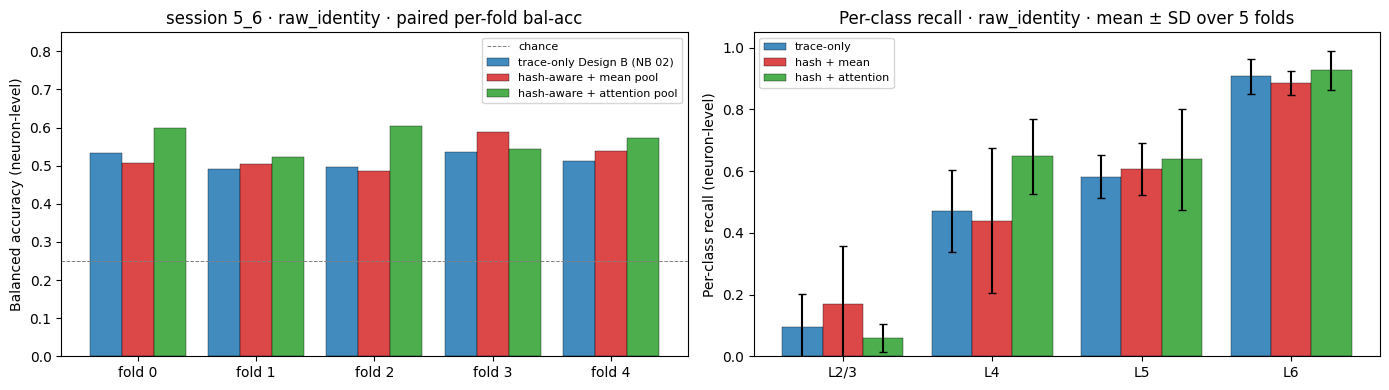

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) Per-fold bal-acc — three-way grouped bars
ax = axes[0]
x = np.arange(N_FOLDS)
w = 0.27
ax.bar(x - w, ba_trace_only, w, label='trace-only Design B (NB 02)',
       color='C0', alpha=0.85, edgecolor='k', linewidth=0.3)
ax.bar(x,     ba_mean,        w, label='hash-aware + mean pool',
       color='C3', alpha=0.85, edgecolor='k', linewidth=0.3)
ax.bar(x + w, ba_attn,        w, label='hash-aware + attention pool',
       color='C2', alpha=0.85, edgecolor='k', linewidth=0.3)
ax.axhline(0.25, color='gray', ls='--', lw=0.7, label='chance')
ax.set_xticks(x); ax.set_xticklabels([f'fold {k}' for k in range(N_FOLDS)])
ax.set_ylabel('Balanced accuracy (neuron-level)')
ax.set_title(f'session {SESSION} · raw_identity · paired per-fold bal-acc')
ax.legend(fontsize=8, loc='upper right')
y_top = max(0.85,
            ba_trace_only.max() + 0.05,
            ba_mean.max() + 0.05,
            ba_attn.max() + 0.05)
ax.set_ylim(0.0, y_top)

# (b) Per-class recall — three-way grouped bars (mean ± SD)
ax = axes[1]
x = np.arange(len(LAYER_CLASSES))
w = 0.27
to_means = np.array([pcr_trace_only[c].mean()      for c in LAYER_CLASSES])
to_stds  = np.array([pcr_trace_only[c].std(ddof=0) for c in LAYER_CLASSES])
me_means = np.array([pcr_mean[c].mean()             for c in LAYER_CLASSES])
me_stds  = np.array([pcr_mean[c].std(ddof=0)        for c in LAYER_CLASSES])
at_means = np.array([pcr_attn[c].mean()             for c in LAYER_CLASSES])
at_stds  = np.array([pcr_attn[c].std(ddof=0)        for c in LAYER_CLASSES])
ax.bar(x - w, to_means, w, yerr=to_stds, capsize=3, label='trace-only',
       color='C0', alpha=0.85, edgecolor='k', linewidth=0.3)
ax.bar(x,     me_means, w, yerr=me_stds, capsize=3, label='hash + mean',
       color='C3', alpha=0.85, edgecolor='k', linewidth=0.3)
ax.bar(x + w, at_means, w, yerr=at_stds, capsize=3, label='hash + attention',
       color='C2', alpha=0.85, edgecolor='k', linewidth=0.3)
ax.set_xticks(x); ax.set_xticklabels(LAYER_CLASSES)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Per-class recall (neuron-level)')
ax.set_title('Per-class recall · raw_identity · mean ± SD over 5 folds')
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

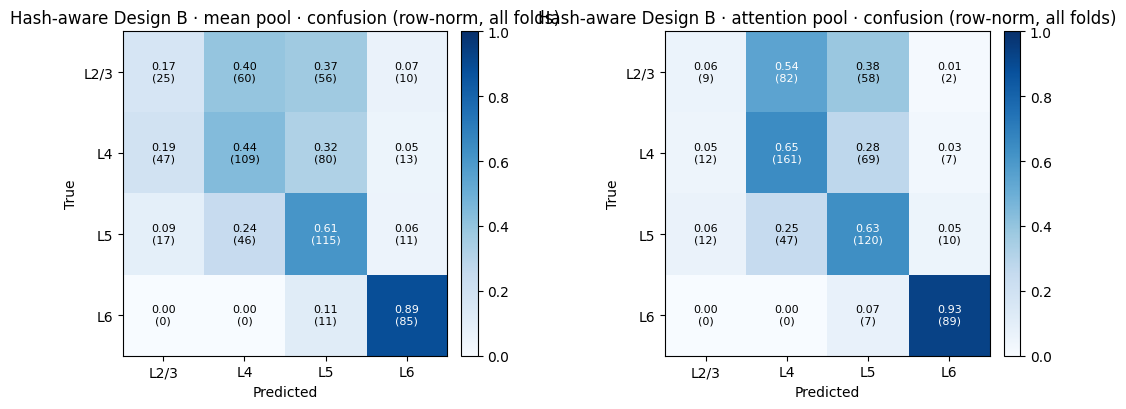

In [12]:
# (c) Two confusion matrices side-by-side (mean pool vs attention pool)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (label, scores) in zip(
        axes,
        [('mean pool',      results['mean']),
         ('attention pool', results['attention'])]):
    C = sum(s['confusion_matrix'] for s in scores)
    C_norm = C / C.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(C_norm, vmin=0, vmax=1, cmap='Blues')
    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            ax.text(j, i, f'{C_norm[i,j]:.2f}\n({C[i,j]})',
                    ha='center', va='center', fontsize=8,
                    color='white' if C_norm[i,j] > 0.5 else 'black')
    ax.set_xticks(range(len(LAYER_CLASSES))); ax.set_xticklabels(LAYER_CLASSES)
    ax.set_yticks(range(len(LAYER_CLASSES))); ax.set_yticklabels(LAYER_CLASSES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Hash-aware Design B · {label} · confusion (row-norm, all folds)')
    plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
plt.tight_layout(); plt.show()

## 11 · Training curves — both pool variants (mean ± SD across folds)

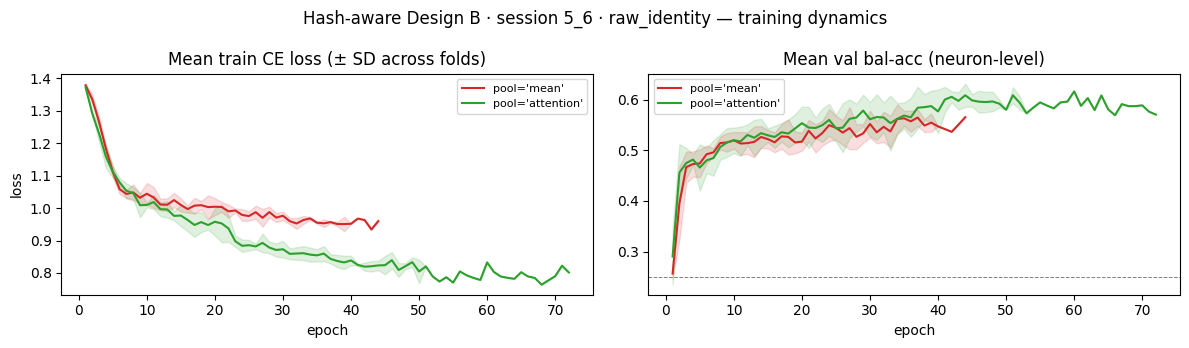

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for pool, color in [('mean', 'C3'), ('attention', 'C2')]:
    hists = histories[pool]
    max_e = max(len(h) for h in hists)
    loss = np.full((len(hists), max_e), np.nan)
    vacc = np.full((len(hists), max_e), np.nan)
    for i, h in enumerate(hists):
        loss[i, :len(h)] = [r['train_loss']  for r in h]
        vacc[i, :len(h)] = [r['val_bal_acc'] for r in h]
    epochs = np.arange(1, max_e + 1)
    axes[0].plot(epochs, np.nanmean(loss, 0), color=color, label=f'pool={pool!r}')
    axes[0].fill_between(epochs,
                         np.nanmean(loss, 0) - np.nanstd(loss, 0),
                         np.nanmean(loss, 0) + np.nanstd(loss, 0),
                         color=color, alpha=0.15)
    axes[1].plot(epochs, np.nanmean(vacc, 0), color=color, label=f'pool={pool!r}')
    axes[1].fill_between(epochs,
                         np.nanmean(vacc, 0) - np.nanstd(vacc, 0),
                         np.nanmean(vacc, 0) + np.nanstd(vacc, 0),
                         color=color, alpha=0.15)
axes[0].set(title='Mean train CE loss (± SD across folds)', xlabel='epoch', ylabel='loss')
axes[1].set(title='Mean val bal-acc (neuron-level)',         xlabel='epoch')
axes[1].axhline(0.25, color='gray', ls='--', lw=0.7)
for ax in axes: ax.legend(fontsize=8)
plt.suptitle(f'Hash-aware Design B · session {SESSION} · raw_identity — training dynamics')
plt.tight_layout(); plt.show()

## 12 · Three-way verdict (per planning §Stage 2.2 a + b + decision-criteria)

The §Stage 2.2b planning rule has two distinct decisions to make:

1. **Does hash identity help at all?** (mean pool vs trace-only)  
   Threshold: Δ ≥ 0.03 bal-acc AND (better macro-F1 OR more balanced per-class recall, especially L2/3).
2. **Does attention help over mean pool?** (attention vs mean)  
   Per planning §Stage 2.2b line 696: "only if it improves **validation** metrics, not only training metrics". We use the same Δ ≥ 0.03 threshold here, but the claim is about pool choice, not architecture.

We also flag **partial improvements** (planning line 947): improving L2/3 recall while damaging another class > 5 pp is reported as partial, not as the new main model.

In [16]:
EPS_DELTA   = 0.01
BIG_DELTA   = 0.03
L23_TARGET  = 0.05
DROP_LIMIT  = 0.05    # any class losing > this → partial improvement, not new main model

def classify_pair(name, d_ba, d_f1, d_pcr):
    """Apply §Stage 2.2 decision criteria to a paired comparison and return
    a list of verdict strings."""
    out = [f'\n── {name} ──']
    other_classes_dropped = [(c, d_pcr[c].mean()) for c in LAYER_CLASSES
                             if c != 'L2/3' and d_pcr[c].mean() < -DROP_LIMIT]
    out.append(f'  Δ_bal_acc={d_ba.mean():+.4f}  ({int((d_ba > 0).sum())}/5)   '
               f'Δ_macro_F1={d_f1.mean():+.4f}   Δ_L2/3={d_pcr["L2/3"].mean():+.4f}')
    if d_ba.mean() >= BIG_DELTA and (d_f1.mean() > EPS_DELTA or d_pcr['L2/3'].mean() > L23_TARGET):
        if other_classes_dropped:
            out.append(f'  PARTIAL IMPROVEMENT: clears bal-acc threshold but '
                       f'{", ".join(f"{c} drops {d:+.3f}" for c,d in other_classes_dropped)}.')
            out.append(f'  Per planning line 947: report as partial, NOT as the new main model.')
        else:
            out.append(f'  CLEAR IMPROVEMENT: clears the §Stage 2.2b threshold (Δ ≥ 0.03 + F1/L2/3 gain).')
    elif d_pcr['L2/3'].mean() > L23_TARGET and d_ba.mean() > EPS_DELTA:
        out.append('  PARTIAL: L2/3 recall gain is meaningful but bal-acc gain below 0.03 threshold.')
    elif abs(d_ba.mean()) <= EPS_DELTA and abs(d_pcr['L2/3'].mean()) <= EPS_DELTA:
        out.append('  NO IMPROVEMENT: both bal-acc Δ and L2/3 recall Δ within ±0.01.')
    elif d_ba.mean() < -EPS_DELTA:
        out.append('  WORSE: this variant is below the reference by Δ ≤ -0.01 in bal-acc.')
    else:
        out.append('  AMBIGUOUS: small Δ that does not clear thresholds in any direction.')
    return out

verdict_lines = ['Stage 2.2 a + b · session 5_6 · raw_identity']
verdict_lines.append(f'\nAbsolute bal-acc means: '
                     f'trace-only={ba_trace_only.mean():.4f}  '
                     f'mean={ba_mean.mean():.4f}  attention={ba_attn.mean():.4f}')
verdict_lines.append(f'Absolute L2/3 recall means: '
                     f'trace-only={pcr_trace_only["L2/3"].mean():.4f}  '
                     f'mean={pcr_mean["L2/3"].mean():.4f}  attention={pcr_attn["L2/3"].mean():.4f}')

for name, d_ba, d_f1, d_pcr in PAIRS:
    verdict_lines.extend(classify_pair(name, d_ba, d_f1, d_pcr))

# --- Pick the winning architecture and emit the next-step recommendation ----
verdict_lines.append('\n──── Recommended next step ────')

d_mean_trace = ba_mean - ba_trace_only
d_attn_trace = ba_attn - ba_trace_only
d_attn_mean  = ba_attn - ba_mean
l23_mean_trace = pcr_mean['L2/3'] - pcr_trace_only['L2/3']
l23_attn_trace = pcr_attn['L2/3'] - pcr_trace_only['L2/3']
l23_attn_mean  = pcr_attn['L2/3'] - pcr_mean['L2/3']

any_pool_helps = (d_mean_trace.mean() >= BIG_DELTA or d_attn_trace.mean() >= BIG_DELTA
                   or l23_mean_trace.mean() > L23_TARGET or l23_attn_trace.mean() > L23_TARGET)
attn_better = (d_attn_mean.mean() >= BIG_DELTA
               or (l23_attn_mean.mean() > L23_TARGET and d_attn_mean.mean() > EPS_DELTA))

if not any_pool_helps:
    verdict_lines.append('NEITHER pool variant clears §Stage 2.2 thresholds vs trace-only Design B.')
    verdict_lines.append('  Per planning §Stage 2.2 line 949, do NOT add more hash-aware complexity.')
    verdict_lines.append('  Alternatives:')
    verdict_lines.append('   (a) Stage 2.3 — replicate strongest existing model on session 5_7;')
    verdict_lines.append('   (b) Direct comparison against Tier G on the same neurons;')
    verdict_lines.append('   (c) Class-weight diagnostic for L2/3 (e.g. 1/sqrt(n_c) instead of 1/n_c).')
elif attn_better:
    verdict_lines.append('ATTENTION POOL is the new candidate model. Per §Stage 2.2b, scale this')
    verdict_lines.append('   architecture in the next stages (controls).')
    verdict_lines.append('   Recommended: Stage 2.2 follow-up — same architecture, baseline-subtracted')
    verdict_lines.append('   condition + temporal controls; OR proceed to Stage 2.3 directly with')
    verdict_lines.append('   hash-aware + attention pool.')
else:
    verdict_lines.append('MEAN POOL is the new candidate model — attention does not improve enough')
    verdict_lines.append('   to justify the extra capacity (and risk of overfitting per §Stage 2.2b).')
    verdict_lines.append('   Recommended: Stage 2.3 — replicate hash-aware Design B + mean pool on 5_7.')

for ln in verdict_lines:
    print(ln)

Stage 2.2 a + b · session 5_6 · raw_identity

Absolute bal-acc means: trace-only=0.5140  mean=0.5247  attention=0.5685
Absolute L2/3 recall means: trace-only=0.0959  mean=0.1685  attention=0.0601

── mean − trace_only ──
  Δ_bal_acc=+0.0107  (3/5)   Δ_macro_F1=+0.0100   Δ_L2/3=+0.0726
  PARTIAL: L2/3 recall gain is meaningful but bal-acc gain below 0.03 threshold.

── attention − trace_only ──
  Δ_bal_acc=+0.0544  (5/5)   Δ_macro_F1=+0.0663   Δ_L2/3=-0.0358
  CLEAR IMPROVEMENT: clears the §Stage 2.2b threshold (Δ ≥ 0.03 + F1/L2/3 gain).

── attention − mean ──
  Δ_bal_acc=+0.0437  (4/5)   Δ_macro_F1=+0.0563   Δ_L2/3=-0.1084
  CLEAR IMPROVEMENT: clears the §Stage 2.2b threshold (Δ ≥ 0.03 + F1/L2/3 gain).

──── Recommended next step ────
ATTENTION POOL is the new candidate model. Per §Stage 2.2b, scale this
   architecture in the next stages (controls).
   Recommended: Stage 2.2 follow-up — same architecture, baseline-subtracted
   condition + temporal controls; OR proceed to Stage 2.3 d

## 13 · Persist results — both pool variants in one parquet

In [15]:
POOL_NOTES = {
    'mean':      'Stage 2.2a hash-aware Design B; pool=mean',
    'attention': 'Stage 2.2b hash-aware Design B; pool=attention',
}
POOL_MODEL_NAME = {
    'mean':      'HashAwareDeepSetsCNN_E1_raw_identity_meanpool',
    'attention': 'HashAwareDeepSetsCNN_E1_raw_identity_attnpool',
}

rows = []
for pool in POOL_KINDS:
    pool_summary = summarise(results[pool])
    pool_ba      = np.array([s['balanced_accuracy'] for s in results[pool]])
    pool_l23     = np.array([s['per_class_recall']['L2/3'] for s in results[pool]])
    d_ba_vs_trace  = pool_ba  - ba_trace_only
    d_l23_vs_trace = pool_l23 - pcr_trace_only['L2/3']
    note_base = (f'{POOL_NOTES[pool]}; '
                 f'trace_embed={TRACE_EMBED} hash_embed={HASH_EMBED} '
                 f'row_hidden={ROW_HIDDEN} head_hidden={HEAD_HIDDEN}; '
                 f'n_hashes={N_HASHES}; mismatch removed; padded T={MAX_TRACE_LEN}; '
                 f'masked GAP per trace')
    for k, score in enumerate(results[pool]):
        rows.append(make_result_row(
            model_name      = POOL_MODEL_NAME[pool],
            input_mode      = 'E1_set_padded_oracle_with_hash',
            normalization   = 'raw',
            stimulus_family = 'all_padded',
            split_protocol  = f'within_session_GKF{N_FOLDS}',
            fold_or_session = f'{SESSION}_fold{k}',
            seed            = SEED + k,
            score_dict      = score,
            notes           = note_base,
        ))
    rows.append({
        'model_name':        POOL_MODEL_NAME[pool],
        'input_mode':        'E1_set_padded_oracle_with_hash',
        'normalization':     'raw',
        'stimulus_family':   'all_padded',
        'split_protocol':    f'within_session_GKF{N_FOLDS}',
        'fold_or_session':   f'{SESSION}_summary',
        'seed':              SEED,
        'n_neurons':         int(np.mean([sc['n_neurons'] for sc in results[pool]])),
        'balanced_accuracy': float(pool_summary['bal_acc_mean']),
        'macro_f1':          float(pool_summary['macro_f1_mean']),
        'recall_L23':        float(pool_summary['recall_L2/3_mean']),
        'recall_L4':         float(pool_summary['recall_L4_mean']),
        'recall_L5':         float(pool_summary['recall_L5_mean']),
        'recall_L6':         float(pool_summary['recall_L6_mean']),
        'notes':             (f'{POOL_NOTES[pool]} SUMMARY (mean over {N_FOLDS} folds); '
                              f'bal_acc_std={pool_summary["bal_acc_std"]:.4f}; '
                              f'Δ_bal_acc_vs_trace_only={d_ba_vs_trace.mean():+.4f}; '
                              f'Δ_L2/3_recall_vs_trace_only={d_l23_vs_trace.mean():+.4f}'),
    })

save_results(rows, 'phase2_stage2_2a_hash_aware_design_b.parquet')
print(f'Saved {len(rows)} rows → data/processed/results/phase2_stage2_2a_hash_aware_design_b.parquet')
print(f'  ({N_FOLDS} per-fold + 1 summary) × 2 pool variants = {2 * (N_FOLDS + 1)} rows expected')

Saved 12 row(s) → data/processed/results/phase2_stage2_2a_hash_aware_design_b.parquet  (total: 12)
Saved 12 rows → data/processed/results/phase2_stage2_2a_hash_aware_design_b.parquet
  (5 per-fold + 1 summary) × 2 pool variants = 12 rows expected


---

### What this notebook does NOT claim

* **No trace-only claim.** Per planning lines 638–639, any improvement over notebook 02 is not evidence that the trace alone contains layer signal — it is evidence that the trace **combined with stimulus identity** does.
* **No cross-session claim.** Within session 5_6 only.
* **No engineered-tier comparison.** Tier-G / Tier-A / multimodal benchmarks remain deferred to the end-of-Phase-2 benchmark notebook.
* **No kinetics claim.** Requires the temporal control suite on whichever architecture wins, plus saliency / occlusion localising signal to evoked windows (planning §11).
* **Attention pool is reported here as a head-to-head comparison, not as a victory lap.** Per §Stage 2.2b, the attention model is preferred only if its *validation* metrics improve.

### Next notebook (decided by §12's verdict)

* **Attention pool wins** (Δ_attn−mean ≥ 0.03 + F1 or L2/3 gain) → Stage 2.2 follow-up: same architecture with baseline-subtracted condition + temporal controls; OR proceed to Stage 2.3 directly with hash-aware + attention pool.
* **Mean pool wins or ties attention** → Stage 2.3: replicate hash-aware Design B + mean pool on session 5_7.
* **Neither pool clears the threshold vs trace-only** → skip Stage 2.2 entirely. Best next step per planning §Stage 2.2 line 949 is Stage 2.3 with the strongest pre-existing model, OR a class-weight diagnostic for the L2/3 collapse.

---

#### Hash identity improved global within-session decoding, especially with attention pooling, but it did not solve the main diagnostic failure on L2/3. Attention pooling is the strongest global model, whereas mean pooling gives the best L2/3 recall but with high fold instability. Therefore, hash identity appears useful, but not sufficient. The next diagnostic step is E1 Design A + hash embeddings to test whether the L2/3 failure is caused by the Design B set aggregation mechanism. E0 Design B and temporal controls are deferred until a candidate model improves both global metrics and the L2/3 failure mode.